In [1]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

C:\Users\TomAH\anaconda3\envs\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
catalog = OceanDataCatalog(catalog_name="noc-stac")
catalog.search(collection='noc-npd-era5', item_name='tn')



            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/MOVE_16N
              Title: M1m/MOVE_16N Icechunk repository
              Description: **Monthly mean ocean physics transect outputs defined at MOVE_16N.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/MOVE_16N')`
              Platform: tn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/SAMBA_34_5S
              Title: M1m/SAMBA_34_5S Icechunk repository
              Description: **Monthly mean global ocean scalar outputs.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/SAMBA_34_5S')`
              Platform: tn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c

In [12]:
ds1 = catalog.open_dataset(id=catalog.Items[10].id).sel(time = slice(np.datetime64('1990-01-01'), np.datetime64('2024-12-31')))

In [13]:
moc = ds1['sf_model'] 
moc

<xarray.DataArray 'sf_model' (time: 420, z: 75)> Size: 252kB
dask.array<getitem, shape=(420, 75), dtype=float64, chunksize=(1, 75), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1990-01-16T12:00:00 ... 2024-12-16T12:...
  * z        (z) float64 600B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
Attributes:
    units:              Sv
    minimum_longitude:  -81.0
    maximum_longitude:  -10.0
    comment:            Overturning streamfunctions using model velocities.

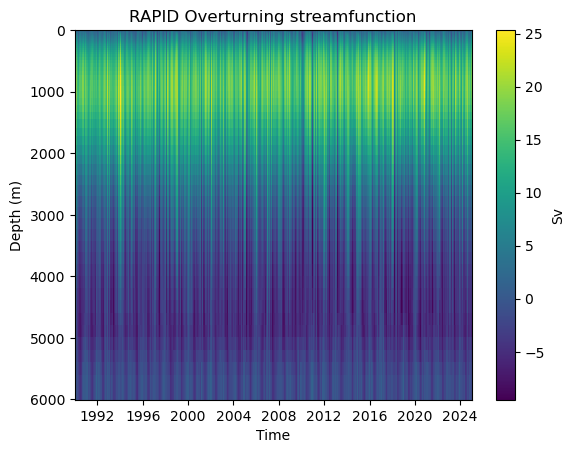

In [14]:
fig, ax = plt.subplots()

pcm = ax.pcolormesh(moc['time'], moc['z'], moc.T, shading='auto')
ax.set_xlabel('Time')
ax.set_ylabel('Depth (m)')
ax.set_title("RAPID Overturning streamfunction")
ax.invert_yaxis()
plt.colorbar(pcm, ax=ax, label='Sv')
# ax.set_xlim(np.datetime64('1990-01-01'), np.datetime64('2024-12-31'))
# ax.set_ylim(26,28)

In [15]:
moc_strength = ds1['mocmax_model'] 

Text(0, 0.5, 'Maximum Overturning Streamfunction (Sv)')

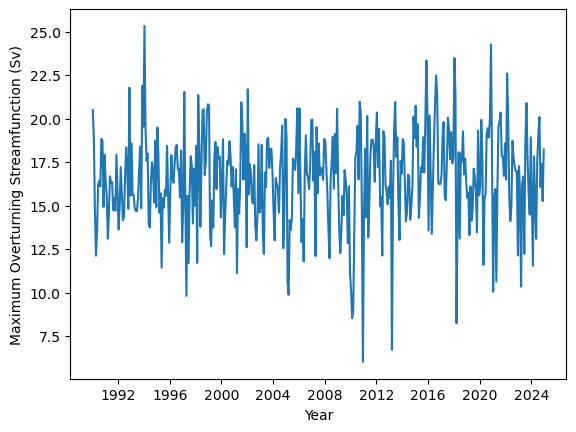

In [16]:
plt.plot(moc_strength['time'], moc_strength)
plt.xlabel('Year')
plt.ylabel('Maximum Overturning Streamfunction (Sv)')

Text(0, 0.5, 'Maximum Overturning Streamfunction (Sv) - Annual Mean')

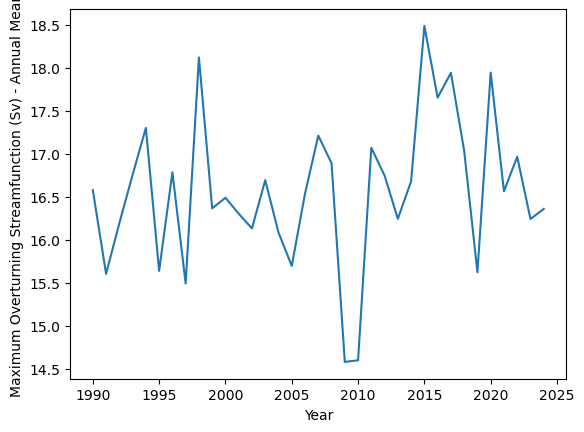

In [17]:
annual_means = moc_strength.groupby('time.year').mean()
plt.plot(annual_means['year'], annual_means)
plt.xlabel('Year')
plt.ylabel('Maximum Overturning Streamfunction (Sv) - Annual Mean')

In [18]:
### Compare to observations 

observations = xr.open_dataset('moc_vertical.nc')['stream_function_mar']
annual_observations = observations.groupby('time.year').mean()
RAPID_annual_maxsf = annual_observations.max(dim = 'depth')

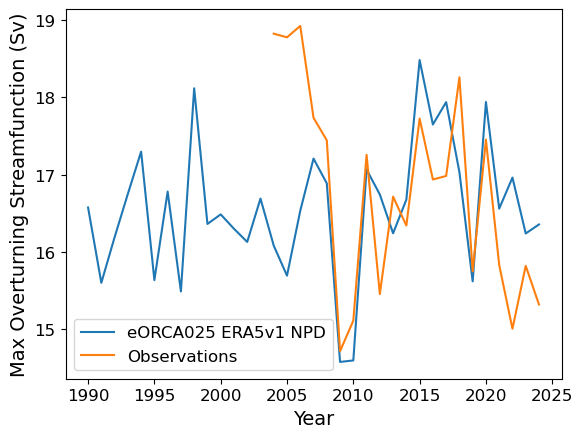

In [19]:
plt.plot(annual_means['year'], annual_means, label = 'eORCA025 ERA5v1 NPD')
plt.plot(RAPID_annual_maxsf['year'], RAPID_annual_maxsf, label = 'Observations')
plt.xlabel('Year', fontsize = 14)
plt.ylabel('Max Overturning Streamfunction (Sv)', fontsize = 14)
plt.legend(loc = 'best', fontsize = 12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('RAPID.png')
plt.show()